# Figure 3 -- De novo generation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from scipy import stats
import seaborn as sns
import re
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.size': 7, 'axes.titlesize': 7, 'axes.labelsize': 7,
    'xtick.labelsize': 6, 'ytick.labelsize': 6, 'legend.fontsize': 6,
    'axes.linewidth': 0.5, 'axes.edgecolor': '#888888',
    'xtick.color': '#555555', 'ytick.color': '#555555',
    'axes.labelcolor': '#333333', 'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.dpi': 300, 'savefig.dpi': 600,
    'xtick.major.width': 0.5, 'ytick.major.width': 0.5,
    'xtick.major.size': 2.5, 'ytick.major.size': 2.5,
})

DATA  = '/home/pszymczak/code/omegamp-dashboard/data/'
BENCH = '/home/pszymczak/code/omegamp-dashboard/benchmark/'

MIC_CEIL      = 128  # highest dilution in the assay (µM)
MIC_COLOR_MAX =  64  # colormap ceiling (µM)
MIC_NAN_FILL  =  64  # untested strains imputed as 64 µM for summary stats

# --- Load tables ---
ref     = pd.read_csv(DATA + 'omegamp_reference_table.csv')
mic     = pd.read_csv(DATA + 'mic.csv')

hc50    = pd.read_csv(DATA + 'hc50.csv')
cc50    = pd.read_csv(DATA + 'cc50.csv')
_dc = lambda v: float(str(v).lstrip('>')) if pd.notna(v) else float('nan')
for _c in mic.columns[1:]:
    mic[_c] = mic[_c].apply(_dc)
hc50['HC50'] = hc50['HC50'].apply(_dc)
cc50['CC50'] = cc50['CC50'].apply(_dc)

npn     = pd.read_csv(DATA + 'npn.csv')
disc    = pd.read_csv(DATA + 'disc.csv')
bestsel = pd.read_csv(DATA + 'bestsel.csv')

# --- Physicochemical scales ---
HYDRO_SCALE = {
    'A':  0.62, 'R': -2.53, 'N': -0.78, 'D': -0.90, 'C':  0.29,
    'Q': -0.85, 'E': -0.74, 'G':  0.48, 'H': -0.40, 'I':  1.38,
    'L':  1.06, 'K': -1.50, 'M':  0.64, 'F':  1.19, 'P':  0.12,
    'S': -0.18, 'T': -0.05, 'W':  0.81, 'Y':  0.26, 'V':  1.08,
}
CHARGE_MAP = {'K': 1, 'R': 1, 'H': 0.5, 'D': -1, 'E': -1}

training     = pd.read_csv(DATA + 'figure2/training/generative-model-dataset.csv')
ref_amps_seq = training[training['IsAMP'] == 1]['Sequence'].tolist()
ref_charges  = [sum(CHARGE_MAP.get(aa, 0) for aa in s.upper()) for s in ref_amps_seq if len(s) > 0]
ref_hydros   = [np.mean([HYDRO_SCALE.get(aa, 0) for aa in s.upper()]) for s in ref_amps_seq if len(s) > 0]
ref_amp_props = pd.DataFrame({'charge': ref_charges, 'hydrophobicity': ref_hydros})

# --- Master dataframe ---
df = ref.merge(hc50, on='short_name', how='left')
df = df.merge(cc50, on='short_name', how='left')
df = df.merge(npn.rename(columns={'MaxRel': 'NPN', 'AUC': 'NPN_AUC'}), on='short_name', how='left')
df = df.merge(disc.rename(columns={'MaxRel': 'DiSC', 'AUC': 'DiSC_AUC'}), on='short_name', how='left')

mic_strains = mic.columns[1:]
mic_vals    = mic[mic_strains].astype(float)
mic['n_strains_le2'] = (mic_vals <= 2).sum(axis=1)
mic['n_strains_le4'] = (mic_vals <= 4).sum(axis=1)
mic['mic50']   = mic_vals.fillna(MIC_NAN_FILL).clip(upper=MIC_CEIL).median(axis=1)
mic['min_mic'] = mic_vals.fillna(MIC_NAN_FILL).clip(upper=MIC_CEIL).min(axis=1)

df = df.merge(
    mic[['short_name', 'n_strains_le2', 'n_strains_le4', 'mic50', 'min_mic']],
    on='short_name', how='left',
)
df['HC50'] = df['HC50'].clip(0.1, MIC_CEIL)
df['CC50'] = df['CC50'].clip(0.1, MIC_CEIL)

# --- De novo subsets ---
de_novo  = df[df['category'] == 'de_novo'].copy()
dn_proto = de_novo[de_novo['generation_mode'] == 'OmegAMP-P']  # prototype-guided
dn_targ  = de_novo[de_novo['generation_mode'] == 'OmegAMP-T']  # targeted
mic_dn   = mic[mic['short_name'].isin(de_novo['short_name'])]

# --- Colormaps ---
mic_cmap = LinearSegmentedColormap.from_list('mic_rb', [
    (0.00, '#b2182b'), (0.25, '#ef8a62'), (0.50, '#f7f7f7'),
    (0.75, '#67a9cf'), (1.00, '#2166ac'),
])
mic_norm = TwoSlopeNorm(vmin=0, vcenter=32, vmax=MIC_COLOR_MAX)

COMP_COLORS = {
    'OmegAMP':       '#EE7733',
    'AMP-Diffusion': '#228833',
    'CLaSS':         '#88CCEE',
    'Joker':         '#EE3377',
}
SS_COLORS = {'Helix': '#5B8FB9', 'Beta': '#B6846C', 'Turn': '#7EB77F', 'Other': '#D1D1D1'}

# --- Lead peptide annotations ---
LEADS = {'Ω-DP-19': 'Ω-DP-19', 'Ω-DP-52': 'Ω-DP-52'}
LEAD_OFFSETS = {
    'Ω-DP-19': {'A': ( 12,  10), 'C': (18,  -5), 'E': (12, -10)},
    'Ω-DP-52': {'A': (-45, -10), 'C': ( 5, -14), 'E': (12, -10)},
}

# --- Strain label map: raw column name → (display name, is_MDR, Gram) ---
STRAIN_MAP_ITALIC = {
    'A. baumannii ATCC 19606 (-)':                  ('$\\it{A. baumannii}$ ATCC 19606',       False, '-'),
    'A. baumannii ATCC BAA-1605 (-) - CGTPACCIMRA': ('$\\it{A. baumannii}$ BAA-1605 (CRAB)',  True,  '-'),
    'E. cloacae ATCC 13047 (-)':                    ('$\\it{E. cloacae}$ ATCC 13047',          False, '-'),
    'E. coli ATCC 11775 (-)':                       ('$\\it{E. coli}$ ATCC 11775',             False, '-'),
    'E. coli AIC221 (-)':                           ('$\\it{E. coli}$ AIC221',                 False, '-'),
    'E. coli AIC222 - CRE (-)':                     ('$\\it{E. coli}$ AIC222 (CRE)',           True,  '-'),
    'E. coli ATCC BAA-3170 (-) - CRE':              ('$\\it{E. coli}$ BAA-3170 (CRE)',         True,  '-'),
    'K. pneumoniae ATCC 13883 (-)':                 ('$\\it{K. pneumoniae}$ ATCC 13883',       False, '-'),
    'K. pneumoniae ATCC BAA-2342 (-) - EIRK':       ('$\\it{K. pneumoniae}$ BAA-2342 (ESBL)', True,  '-'),
    'P. aeruginosa PAO1 (-)':                       ('$\\it{P. aeruginosa}$ PAO1',             False, '-'),
    'P. aeruginosa PA14 (-)':                       ('$\\it{P. aeruginosa}$ PA14',             False, '-'),
    'P. aeruginosa ATCC BAA-3197 (-) - FBCRP':      ('$\\it{P. aeruginosa}$ BAA-3197 (FQR)',  True,  '-'),
    'S. enterica ATCC 9150 (-)':                    ('$\\it{S. enterica}$ ATCC 9150',          False, '-'),
    'S. enterica Typhimurtium ATCC 700720':          ('$\\it{S. enterica}$ Typhimurium',        False, '-'),
    'B. subtilis ATCC 23857 (+)':                   ('$\\it{B. subtilis}$ ATCC 23857',         False, '+'),
    'S. aureus ATCC 12600 (+)':                     ('$\\it{S. aureus}$ ATCC 12600',           False, '+'),
    'S. aureus ATCC BAA-1556 - MRSA (+)':           ('$\\it{S. aureus}$ BAA-1556 (MRSA)',      True,  '+'),
    'E. faecalis ATCC 700802 - VRE (+)':            ('$\\it{E. faecalis}$ 700802 (VRE)',       True,  '+'),
    'E. faecium ATCC 700221 - VRE (+)':             ('$\\it{E. faecium}$ 700221 (VRE)',        True,  '+'),
    'E. coli K-12 BW25113 (-)':                     ('$\\it{E. coli}$ K-12 BW25113',           False, '-'),
}

def annotate_lead(ax, x, y, label, offset=(12, 8)):
    ax.annotate(label, (x, y), fontsize=6, ha='left', va='center', color='black',
                xytext=offset, textcoords='offset points',
                arrowprops=dict(arrowstyle='-', color='#555', lw=0.5), zorder=10)

print(f"De novo: {len(de_novo)} (prototype={len(dn_proto)}, targeted={len(dn_targ)})")
print(f"Training AMPs for background: {len(ref_amp_props):,}")



De novo: 95 (prototype=85, targeted=10)
Training AMPs for background: 35,878


  export box: 6.41 x 7.80 in (x +0.02..6.44, y +0.09..7.88; Cell max 6.5 x 8)


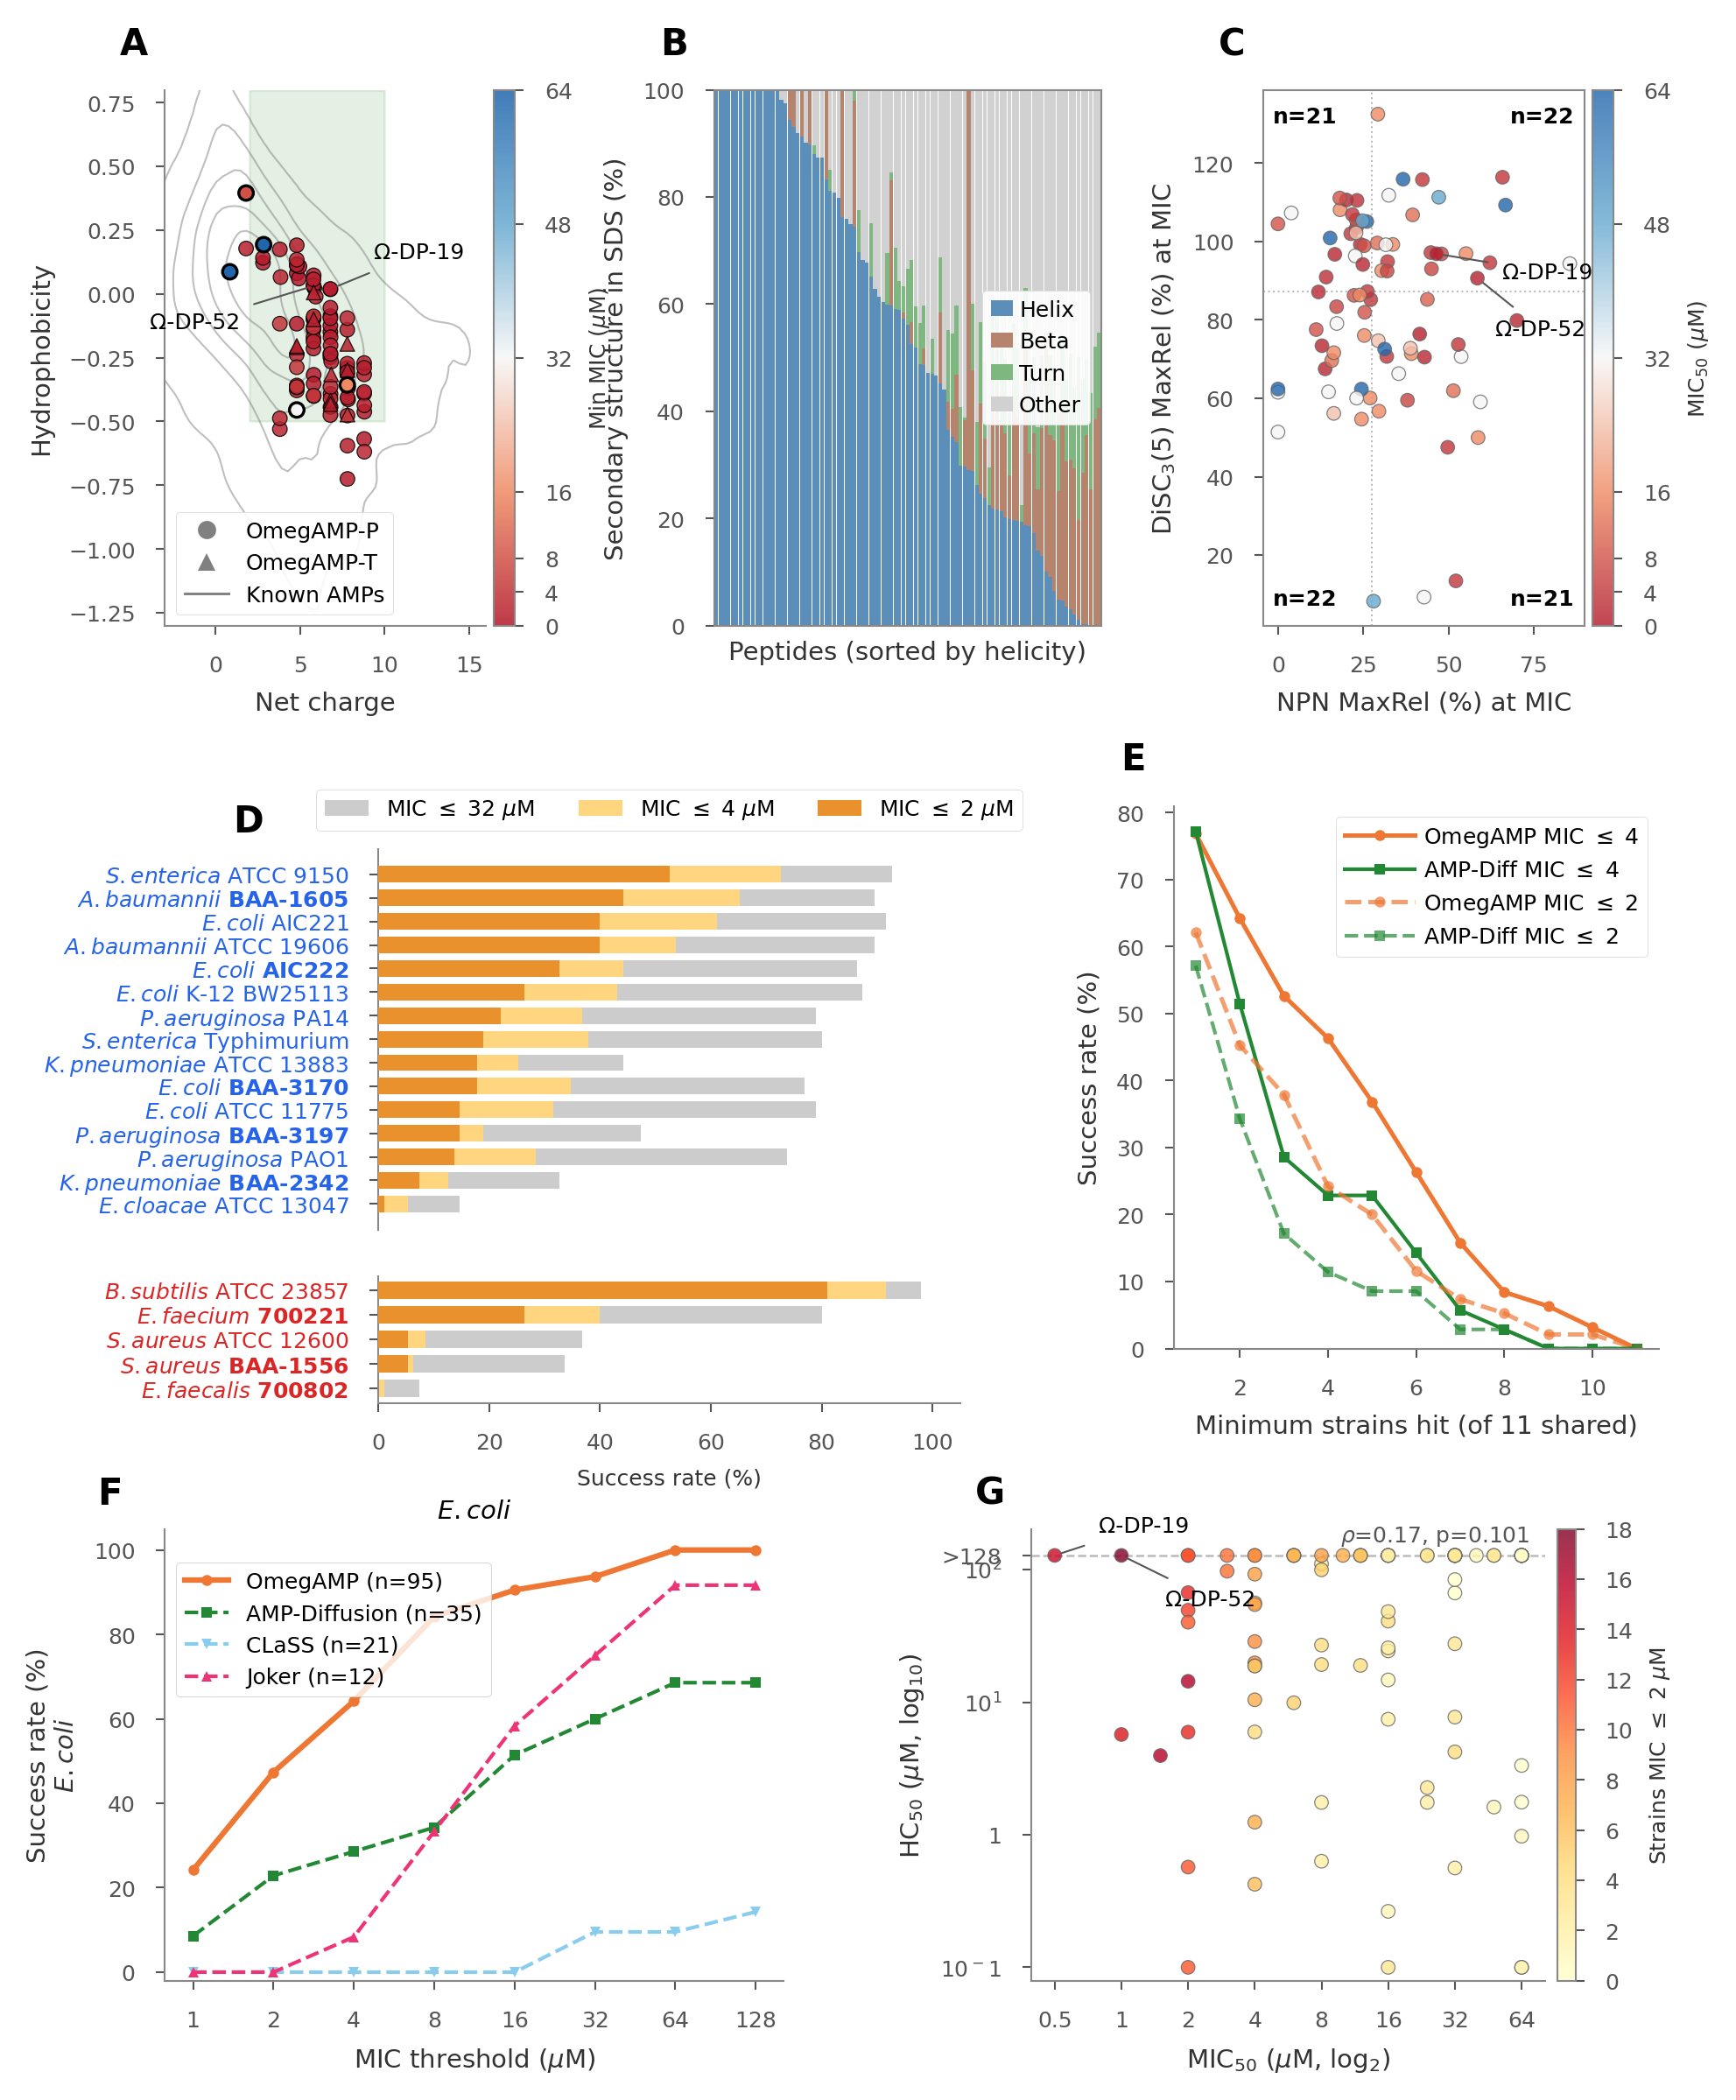

Saved figure3_denovo


In [2]:
# ── Figure layout ───────────────────────────────────────────────────────────────
fig    = plt.figure(figsize=(6.5, 8.0), dpi=300)
# left/right/top margins keep the y-labels, panel letters and tick labels inside the
# 6.5 x 8 in canvas: they sit outside the axes and bbox_inches='tight' exports them.
gs_top = gridspec.GridSpec(1, 3, figure=fig, left=0.085, right=0.955, top=0.955, bottom=0.70, wspace=0.42)
# left=0.21: panel D's strain names are ~1.3 in wide and sit outside the axes
gs_mid = gridspec.GridSpec(1, 2, figure=fig, left=0.21, right=0.96, top=0.64, bottom=0.33, wspace=0.40, width_ratios=[1.2, 1])
gs_bot = gridspec.GridSpec(1, 2, figure=fig, left=0.085, right=0.955, top=0.27, bottom=0.055, wspace=0.40)
PANEL_LABEL = dict(fontsize=10, fontweight='bold', va='top', ha='left')

# ── A: charge × hydrophobicity, coloured by min MIC ─────────────────────────────
ax = fig.add_subplot(gs_top[0])
ax.text(-0.14, 1.12, 'A', transform=ax.transAxes, **PANEL_LABEL)

ax.add_patch(Rectangle((2, -0.5), 8, 1.3, linewidth=0.6,
                        edgecolor='#228B22', facecolor='#228B22', alpha=0.12, zorder=0))
sns.kdeplot(data=ref_amp_props, x='charge', y='hydrophobicity',
            levels=6, color='gray', linewidths=0.5, alpha=0.5, ax=ax)

for grp, marker, ms in [(dn_proto, 'o', 16), (dn_targ, '^', 16)]:
    grp_sorted = grp.sort_values('min_mic', ascending=True, na_position='first')
    sc = ax.scatter(grp_sorted['net_charge'], grp_sorted['mean_hydrophobicity'],
                    c=grp_sorted['min_mic'].clip(0, MIC_COLOR_MAX).fillna(MIC_COLOR_MAX),
                    cmap=mic_cmap, norm=mic_norm,
                    marker=marker, s=ms, edgecolor='black', linewidth=0.3, alpha=0.85, zorder=3)
    # Redraw inactive peptides (min MIC > 4 µM) with bolder edges so they stay
    # distinguishable in the white-blue colour range
    inactive = grp[grp['min_mic'] > 4]
    if len(inactive) > 0:
        ax.scatter(inactive['net_charge'], inactive['mean_hydrophobicity'],
                   c=inactive['min_mic'].clip(0, MIC_COLOR_MAX),
                   cmap=mic_cmap, norm=mic_norm,
                   marker=marker, s=ms, edgecolor='black', linewidth=0.8, alpha=1.0, zorder=5)
    for _, row in grp.iterrows():
        if row['short_name'] in LEADS:
            annotate_lead(ax, row['net_charge'], row['mean_hydrophobicity'],
                          LEADS[row['short_name']], LEAD_OFFSETS[row['short_name']]['A'])

cb = plt.colorbar(sc, ax=ax, shrink=1.0, pad=0.02, aspect=25)
cb.set_label('Min MIC ($\\mu$M)', fontsize=6)
cb.set_ticks([0, 4, 8, 16, 32, 48, 64])
cb.ax.tick_params(labelsize=6)
ax.set_xlabel('Net charge')
ax.set_ylabel('Hydrophobicity')
ax.set_xlim(-3, 16)
ax.set_ylim(-1.3, 0.8)
ax.legend(
    [Line2D([], [], marker='o', color='w', markerfacecolor='gray', markeredgecolor='k', ms=5, lw=0),
     Line2D([], [], marker='^', color='w', markerfacecolor='gray', markeredgecolor='k', ms=5, lw=0),
     Line2D([], [], color='gray', lw=0.7)],
    ['OmegAMP-P', 'OmegAMP-T', 'Known AMPs'],
    fontsize=6, loc='lower left', frameon=True, framealpha=0.9, edgecolor='#ddd',
).set_zorder(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── B: secondary structure in SDS ───────────────────────────────────────────────
ax = fig.add_subplot(gs_top[1])
ax.text(-0.14, 1.12, 'B', transform=ax.transAxes, **PANEL_LABEL)

bestsel_dn = (bestsel
              .merge(ref[['short_name', 'category']], on='short_name')
              .query("category == 'de_novo'")
              .sort_values('fH_SDS_H2O', ascending=False)
              .reset_index(drop=True))
x = np.arange(len(bestsel_dn))

bottom = bestsel_dn['fH_SDS_H2O'].values.copy()
ax.bar(x, bestsel_dn['fH_SDS_H2O'], width=0.9, color=SS_COLORS['Helix'], label='Helix')

beta = (bestsel_dn['f_beta_anti_SDS_H2O'] + bestsel_dn['f_beta_par_SDS_H2O']).values
ax.bar(x, beta, bottom=bottom, width=0.9, color=SS_COLORS['Beta'], label='Beta')
bottom += beta

ax.bar(x, bestsel_dn['fturn_SDS_H2O'], bottom=bottom, width=0.9, color=SS_COLORS['Turn'], label='Turn')
bottom += bestsel_dn['fturn_SDS_H2O'].values

ax.bar(x, bestsel_dn['fothers_SDS_H2O'], bottom=bottom, width=0.9, color=SS_COLORS['Other'], label='Other')

ax.set_ylabel('Secondary structure in SDS (%)')
ax.set_xlabel('Peptides (sorted by helicity)')
ax.set_xlim(-0.5, len(bestsel_dn) - 0.5)
ax.set_ylim(0, 100)
ax.set_xticks([])
ax.legend(fontsize=6, loc='center right', frameon=True, framealpha=0.9, edgecolor='#ddd',
          handlelength=1, handletextpad=0.3)

# ── C: NPN × DiSC mechanism scatter ─────────────────────────────────────────────
ax = fig.add_subplot(gs_top[2])
ax.text(-0.14, 1.12, 'C', transform=ax.transAxes, **PANEL_LABEL)

dn_mech  = de_novo.dropna(subset=['NPN', 'DiSC', 'mic50']).copy()
npn_med  = dn_mech['NPN'].median()
disc_med = dn_mech['DiSC'].median()

sc = ax.scatter(dn_mech['NPN'], dn_mech['DiSC'],
                c=dn_mech['mic50'].clip(0, MIC_COLOR_MAX).fillna(MIC_COLOR_MAX),
                cmap=mic_cmap, norm=mic_norm,
                s=14, alpha=0.8, edgecolors='#666', linewidth=0.3, zorder=3)
ax.axvline(npn_med,  color='#bbb', ls=':', lw=0.5)
ax.axhline(disc_med, color='#bbb', ls=':', lw=0.5)

for (xf, yf, ha, va), cond in [
    ((0.03, 0.97, 'left',  'top'),    (dn_mech['NPN'] <  npn_med) & (dn_mech['DiSC'] >= disc_med)),
    ((0.97, 0.97, 'right', 'top'),    (dn_mech['NPN'] >= npn_med) & (dn_mech['DiSC'] >= disc_med)),
    ((0.03, 0.03, 'left',  'bottom'), (dn_mech['NPN'] <  npn_med) & (dn_mech['DiSC'] <  disc_med)),
    ((0.97, 0.03, 'right', 'bottom'), (dn_mech['NPN'] >= npn_med) & (dn_mech['DiSC'] <  disc_med)),
]:
    ax.text(xf, yf, f'n={cond.sum()}', transform=ax.transAxes,
            fontsize=6, fontweight='bold', ha=ha, va=va, color='black')

for _, row in dn_mech.iterrows():
    if row['short_name'] in LEADS:
        annotate_lead(ax, row['NPN'], row['DiSC'],
                      LEADS[row['short_name']], LEAD_OFFSETS[row['short_name']]['C'])

ax.set_xlabel('NPN MaxRel (%) at MIC')
ax.set_ylabel('DiSC$_3$(5) MaxRel (%) at MIC')
cb = plt.colorbar(sc, ax=ax, shrink=1.0, pad=0.02, aspect=25)
cb.set_label('MIC$_{50}$ ($\\mu$M)', fontsize=6)
cb.set_ticks([0, 4, 8, 16, 32, 48, 64])
cb.ax.tick_params(labelsize=6)

# ── D: per-strain breadth (Gram-negative top, Gram-positive bottom) ──────────────
mic_vals_dn = mic_dn[mic_strains].astype(float)
n_total = len(mic_dn)

strain_rows = []
for s in mic_strains:
    vals = mic_vals_dn[s]
    label, is_mdr, gram = STRAIN_MAP_ITALIC.get(s, (s[:30], False, '-'))
    name = re.sub(r'\s*\(.*?\)', '', label).strip()
    strain_rows.append({
        'name':     name,
        'potent':   (vals <=  2).sum() / n_total * 100,
        'active':   (vals <=  4).sum() / n_total * 100,
        'moderate': (vals <= 32).sum() / n_total * 100,
        'mdr':  is_mdr,
        'gram': gram,
    })
strain_df   = pd.DataFrame(strain_rows).sort_values('potent', ascending=True).reset_index(drop=True)
strains_neg = strain_df[strain_df['gram'] == '-'].reset_index(drop=True)
strains_pos = strain_df[strain_df['gram'] == '+'].reset_index(drop=True)

gs_d = gridspec.GridSpecFromSubplotSpec(
    3, 1, subplot_spec=gs_mid[0],
    height_ratios=[2, len(strains_neg), len(strains_pos)],
    hspace=0.25,
)

def _strain_barh(ax, strains):
    y = np.arange(len(strains))
    ax.barh(y, strains['moderate'], height=0.7, color='#CCCCCC', label='MIC $\\leq$ 32 $\\mu$M', zorder=1)
    ax.barh(y, strains['active'],   height=0.7, color='#FFD580', label='MIC $\\leq$ 4 $\\mu$M',  zorder=2)
    ax.barh(y, strains['potent'],   height=0.7, color='#E8912D', label='MIC $\\leq$ 2 $\\mu$M',  zorder=3)
    ax.set_yticks(y)
    tick_labels = ax.set_yticklabels(strains['name'], fontsize=6)
    for i, (_, row) in enumerate(strains.iterrows()):
        tick_labels[i].set_color('#DC2626' if row['gram'] == '+' else '#2563EB')
        if row['mdr']:
            tick_labels[i].set_fontweight('bold')
    ax.set_xlim(0, 105)
    ax.set_xlabel('Success rate (%)', fontsize=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax_neg = fig.add_subplot(gs_d[1])
ax_neg.text(-0.25, 1.12, 'D', transform=ax_neg.transAxes, **PANEL_LABEL)
_strain_barh(ax_neg, strains_neg)
# Remove x-axis from upper subplot; ax_pos below carries the shared axis
ax_neg.set_xlabel('')
ax_neg.tick_params(axis='x', bottom=False, labelbottom=False)
ax_neg.spines['bottom'].set_visible(False)
ax_neg.legend(fontsize=6, bbox_to_anchor=(0.5, 1.02), loc='lower center', ncol=3,
              frameon=True, framealpha=0.9, edgecolor='#ddd')

ax_pos = fig.add_subplot(gs_d[2])
_strain_barh(ax_pos, strains_pos)

# ── E: multi-strain breadth vs AMP-Diffusion ────────────────────────────────────
gs_e = gridspec.GridSpecFromSubplotSpec(
    3, 1, subplot_spec=gs_mid[1], height_ratios=[0.5, 5, 0.5], hspace=0,
)
ax = fig.add_subplot(gs_e[1])
ax.text(-0.11, 1.12, 'E', transform=ax.transAxes, **PANEL_LABEL)

try:
    ad = pd.read_csv(BENCH + 'amp-diffusion.csv')
except FileNotFoundError:
    ad = pd.DataFrame()

if len(ad) > 0:
    strain_map_ad = {}
    for ad_strain in ad['strain'].unique():
        al = ad_strain.lower()
        for omega_col in mic_strains:
            ol = omega_col.lower()
            for key in ['19606', '1605', '11775', 'aic221', 'aic222', '13883',
                        'pao1', 'pa14', '12600', '1556', '700802', '700221']:
                if key in al and key in ol:
                    strain_map_ad[ad_strain] = omega_col
                    break

    shared = sorted(strain_map_ad.keys())
    for thresh, ls, alpha in [(4, '-', 1.0), (2, '--', 0.7)]:
        omega_hits = [
            sum(1 for s in shared if float(r[strain_map_ad[s]]) <= thresh)
            for _, r in mic_dn.iterrows()
        ]
        ad_hits = []
        for pid in ad['peptide_id'].unique():
            pep_rows = ad[(ad['peptide_id'] == pid) & (ad['mic_relation'] == '=')]
            ad_hits.append(
                sum(1 for s in shared
                    if s in pep_rows['strain'].values
                    and pep_rows[pep_rows['strain'] == s]['mic'].values[0] <= thresh)
            )
        x_range = range(1, len(shared) + 1)
        ax.plot(x_range,
                [sum(c >= n for c in omega_hits) / len(omega_hits) * 100 for n in x_range],
                f'o{ls}', color=COMP_COLORS['OmegAMP'], ms=3, alpha=alpha, lw=1.2,
                label=f'OmegAMP MIC $\\leq$ {thresh}')
        ax.plot(x_range,
                [sum(c >= n for c in ad_hits) / len(ad_hits) * 100 for n in x_range],
                f's{ls}', color=COMP_COLORS['AMP-Diffusion'], ms=3, alpha=alpha, lw=1.0,
                label=f'AMP-Diff MIC $\\leq$ {thresh}')

    ax.set_xlabel(f'Minimum strains hit (of {len(shared)} shared)')
    ax.set_ylabel('Success rate (%)')
    # handlelength=3.2: at the default 2.0 a dashed handle fits only one dash gap,
    # and the centred marker covers it, so MIC <= 2 read as solid in the legend.
    ax.legend(fontsize=6, loc='upper right', frameon=True, framealpha=0.9, edgecolor='#ddd',
              handlelength=3.2, handletextpad=0.4)
    ax.set_xlim(0.5, len(shared) + 0.5)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── F: E. coli MIC benchmark comparison ─────────────────────────────────────────
ax = fig.add_subplot(gs_bot[0])
ax.text(-0.11, 1.12, 'F', transform=ax.transAxes, **PANEL_LABEL)

_AA_MASS = {
    'A':  71.0788, 'R': 156.1875, 'N': 114.1038, 'D': 115.0886, 'C': 103.1388,
    'Q': 128.1307, 'E': 129.1155, 'G':  57.0519, 'H': 137.1411, 'I': 113.1594,
    'L': 113.1594, 'K': 128.1741, 'M': 131.1926, 'F': 147.1766, 'P':  97.1167,
    'S':  87.0782, 'T': 101.1051, 'W': 186.2132, 'Y': 163.1760, 'V':  99.1326,
}

def seq_mw_kda(seq):
    if not isinstance(seq, str) or not any(c.isalpha() for c in seq):
        return 2.0
    return (sum(_AA_MASS.get(aa, 111.1) for aa in seq.upper() if aa.isalpha()) + 18.0153) / 1000

thresholds_uM = [1, 2, 4, 8, 16, 32, 64, 128]
ecoli_cols    = [c for c in mic_strains if 'E. coli' in c and 'K-12' not in c]
omega_best    = mic_dn[ecoli_cols].astype(float).min(axis=1)
n_omega       = len(de_novo)

ax.plot(thresholds_uM,
        [(omega_best <= t).sum() / n_omega * 100 for t in thresholds_uM],
        'o-', color=COMP_COLORS['OmegAMP'], ms=3, lw=1.5,
        label=f'OmegAMP (n={n_omega})', zorder=5)

for name, fn, marker in [('AMP-Diffusion', 'amp-diffusion.csv', 's'),
                          ('CLaSS',         'class.csv',         'v'),
                          ('Joker',         'joker.csv',         '^')]:
    try:
        comp = pd.read_csv(BENCH + fn)
    except FileNotFoundError:
        continue
    ecoli_rows = comp[comp['strain'].str.contains('Escherichia coli|E. coli', case=False, na=False)]
    if len(ecoli_rows) == 0:
        continue
    if ecoli_rows['mic_unit'].iloc[0] == 'ug/mL':
        mw_map  = comp.drop_duplicates('peptide_id').set_index('peptide_id')['sequence'].map(seq_mw_kda)
        eq_rows = ecoli_rows[ecoli_rows['mic_relation'] == '='].copy()
        eq_rows['mic_uM'] = eq_rows.apply(lambda r: r['mic'] / mw_map.get(r['peptide_id'], 2.0), axis=1)
        best = eq_rows.groupby('peptide_id')['mic_uM'].min()
    else:
        best = ecoli_rows[ecoli_rows['mic_relation'] == '='].groupby('peptide_id')['mic'].min()
    n_comp = comp['peptide_id'].nunique()
    ax.plot(thresholds_uM,
            [(best <= t).sum() / n_comp * 100 for t in thresholds_uM],
            f'{marker}--', color=COMP_COLORS.get(name, '#999'), ms=3, lw=1.0,
            label=f'{name} (n={n_comp})')

ax.set_xscale('log', base=2)
ax.set_xticks(thresholds_uM)
ax.set_xticklabels(thresholds_uM, fontsize=6)
ax.set_xlabel('MIC threshold ($\\mu$M)')
ax.set_ylabel('Success rate (%)\n$\\it{E. coli}$')
ax.set_title('$\\it{E. coli}$', fontsize=7, pad=3)
ax.set_ylim(-2, 105)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
leg = ax.legend(fontsize=6, loc='upper left', frameon=True, framealpha=0.8,
                edgecolor='#ccc', bbox_to_anchor=(0.0, 0.95))
leg.get_frame().set_facecolor('white')
leg.set_zorder(10)

# ── G: MIC₅₀ vs HC₅₀ (potency vs haemolysis) ────────────────────────────────────
ax = fig.add_subplot(gs_bot[1])
ax.text(-0.11, 1.12, 'G', transform=ax.transAxes, **PANEL_LABEL)

dn_safe = de_novo.dropna(subset=['mic50', 'HC50']).copy()
dn_safe['log2_mic50'] = np.log2(dn_safe['mic50'].clip(0.5))
dn_safe['log10_hc50'] = np.log10(dn_safe['HC50'].clip(0.1))

sc = ax.scatter(dn_safe['log2_mic50'], dn_safe['log10_hc50'],
                c=dn_safe['n_strains_le2'],
                cmap='YlOrRd', s=14, alpha=0.8, edgecolors='#666', linewidth=0.3,
                vmin=0, vmax=18, zorder=3)

# Spearman on raw (untransformed) values; log axes are for display only
r_s, p_s = stats.spearmanr(dn_safe['mic50'], dn_safe['HC50'])
p_str = 'p<0.001' if p_s < 0.001 else f'p={p_s:.3f}'
ax.text(0.97, 1.01, f'$\\rho$={r_s:.2f}, {p_str}',
        transform=ax.transAxes, fontsize=6, ha='right', va='top', color='#555')

LEAD_OFFSETS_G = {'Ω-DP-19': (12, 8), 'Ω-DP-52': (12, -12)}
for _, row in dn_safe.iterrows():
    if row['short_name'] in LEADS:
        annotate_lead(ax, row['log2_mic50'], row['log10_hc50'],
                      LEADS[row['short_name']], LEAD_OFFSETS_G[row['short_name']])

lo_x, hi_x = int(np.floor(dn_safe['log2_mic50'].min())), int(np.ceil(dn_safe['log2_mic50'].max()))
ticks_x = list(range(lo_x, hi_x + 1))
ax.set_xticks(ticks_x)
ax.set_xticklabels([str(int(2**t)) if t >= 0 else f'{2**t:.1f}' for t in ticks_x])

CEIL_LOG = np.log10(128)
lo_y = int(np.floor(dn_safe['log10_hc50'].min()))
int_ticks = list(range(lo_y, int(np.floor(CEIL_LOG)) + 1))
ticks_y  = int_ticks + [CEIL_LOG]
labels_y = [('1' if t == 0 else f'$10^{t}$') for t in int_ticks] + ['>128']
ax.set_yticks(ticks_y)
ax.set_yticklabels(labels_y)
ax.set_ylim(lo_y - 0.1, CEIL_LOG + 0.2)
ax.axhline(CEIL_LOG, color='#bbb', ls='--', lw=0.6, zorder=1)

ax.set_xlabel('MIC$_{50}$ ($\\mu$M, log$_2$)')
ax.set_ylabel('HC$_{50}$ ($\\mu$M, log$_{10}$)')
cb = plt.colorbar(sc, ax=ax, shrink=1.0, pad=0.02, aspect=25)
cb.set_label('Strains MIC $\\leq$ 2 $\\mu$M', fontsize=6)
cb.ax.tick_params(labelsize=6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Save ────────────────────────────────────────────────────────────────────────
OUT = '/home/pszymczak/code/omegamp-dashboard/figures/figure3_denovo'
# Cell limits: exported box <= 6.5 x 8 in, every font >= 6 pt. bbox_inches='tight'
# grows past the canvas when an artist sits outside it, so check the real box.
fig.canvas.draw()
_tb = fig.get_tightbbox(fig.canvas.get_renderer())
print(f"  export box: {_tb.width:.2f} x {_tb.height:.2f} in "
      f"(x {_tb.x0:+.2f}..{_tb.x1:.2f}, y {_tb.y0:+.2f}..{_tb.y1:.2f}; Cell max 6.5 x 8)")

plt.savefig(OUT + '.pdf', bbox_inches='tight', pad_inches=0.02)
plt.savefig(OUT + '.svg', bbox_inches='tight', pad_inches=0.02)
plt.savefig(OUT + '.png', dpi=600, bbox_inches='tight', pad_inches=0.02)
plt.show()
print("Saved figure3_denovo")